In [28]:
import math
import matplotlib.pyplot as plt
import numpy as np

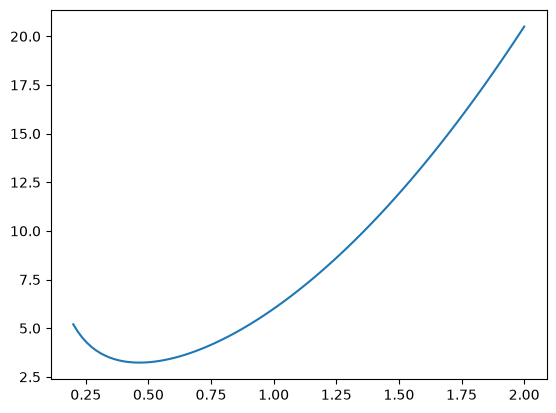

In [29]:
def f_base(x):
    ans = 5 * x**2 + 1 / x
    return ans

def d_base(x):
    ans = 10*x - 1/x**2
    return ans

# graph
xs = np.linspace(0.2, 2, 100)
fs = np.array(list(map(f_base, xs)))
# ds = np.array(list(map(d_base, xs)))


plt.plot(xs, fs)
# plt.plot(xs, ds)
plt.show()

In [37]:
# Метод средней точки
def method_1(a, b, eps):
    iter_c = 0
    f_call_c = 0

    def f(x):
        nonlocal f_call_c
        f_call_c += 1
        return f_base(x)

    def d(x):
        nonlocal f_call_c
        f_call_c += 1
        return d_base(x)

    x = (a+b)/2
    d_x = d(x)

    while abs(a - b) > eps or abs(d_x) > eps:
        iter_c += 1
        if d_x > 0:
            b = x
        else: 
            a = x
        x = (a+b)/2
        d_x = d(x)
        
    
    return (x, f(x), iter_c, f_call_c)

In [31]:
# Метод Брента
def method_2(a, b, eps):
    iter_c = 0
    f_call_c = 0

    def f(x):
        nonlocal f_call_c
        f_call_c += 1
        return f_base(x)
    f_a = f(a)
    f_b = f(b)
    x = a + (3 - math.sqrt(5)) / 2 * (b - a)
    f_x = f(x)
    e = 0


    while max(x - a, b - x) > 2 * eps:
        iter_c += 1
        m = (a + b) / 2
        p = math.pow(b - x, 2) * (f_a - f_x) - math.pow(x - a, 2) * (f_b - f_x)
        q = 2 * ((b - x)*(f_a - f_x) + (x - a)*(f_b - f_x))
        s = x + p/q

        if (q == 0 and abs(e) < eps and (s < a or s > b)) or abs(p/q) > abs(e)/2:
            if x >= m:
                u = (math.sqrt(5) - 1) / 2 * x + (3 - math.sqrt(5)) / 2 * a
                f_u = f(u)
            else:
                u = (math.sqrt(5) - 1) / 2 * x + (3 - math.sqrt(5)) / 2 * b
                f_u = f(u)
        else:
            u = x + p/q
            f_u = f(u)
            if (abs(u - x) < 2*eps and u - a < 2*eps) or (b - u) < 2*eps:
                u = x + eps * np.sign(p/q)
                f_u = f(u)

        if f_u <= f_x:
            if (u < x):
                b = x
            else:
                a = x
            x = u
            f_x = f_u
        else: 
            if (u < x):
                a = u
            else:
                b = u
    return (x, f_x, iter_c, f_call_c)

In [38]:
a = 0.2
b = 2
eps = 0.0002

(xm_1, f_xm_1, iter_c_1, f_call_c_1) = method_1(a, b, eps)
print(iter_c_1, f_call_c_1, xm_1, f_xm_1)

(xm_2, f_xm_2, iter_c_2, f_call_c_2) = method_2(a, b, eps)
print(iter_c_2, f_call_c_2, xm_2, f_xm_2)

# (xm_3, f_xm_3, iter_c_3, f_call_c_3) = method_3(a, b, eps)
# print(iter_c_3, f_call_c_3, xm_3, f_xm_3)

16 18 0.4641525268554688 3.2316520356539087
17 20 0.46424763462419316 3.2316521531845672
